# TP10 — Mesurer l'impact et prévoir la suite

**Cas d'usage 01 — Certification IA : Résiliation client SaaS (churn)**

| | |
|---|---|
| **Objectif** | Traduire les statistiques en résultat concret pour l'entreprise (comptes sauvés, en euros), et prévoir comment garder le modèle à jour. |
| **Livrable** | Une estimation chiffrée de l'impact métier + un plan de monitoring et de ré-entraînement. |
| **Enjeu** | Un modèle qui a raison aujourd'hui peut se tromper demain — le monde change. Comment le surveiller et savoir quand le ré-entraîner ? |
| **Compétences** | C8 (mesurer performance & impacts), C9 (amélioration continue) |

> Dernier TP avant le notebook certifiant final. Reprend le modèle et le seuil du
> TP6 (régression logistique, seuil ≈0.44, capacité CS 40%).

## §0 — Setup : recharger le modèle et le test set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sklearn.model_selection import train_test_split
from pathlib import Path
from scipy import stats

Path("figures").mkdir(exist_ok=True)
RANDOM_STATE = 42
SEUIL_DECISION = 0.44  # retenu en TP6, capacité CS ~40%
COUT_CONTACT_EUR = 50   # estimation TP6

db_url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user", password="ThEP@ssW0rd",
    host="localhost", port=5432, database="churn_saas_db",
)
engine = create_engine(db_url)
df = pd.read_sql("SELECT * FROM clients_churn", engine)

model_churn = joblib.load("models/model_churn.joblib")
metadata = json.loads((Path("models") / "metadata.json").read_text(encoding="utf-8"))
FEATURE_COLS = metadata["feature_cols"]

X = df[FEATURE_COLS]
y = df["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
clv_test = df.loc[X_test.index, "valeur_vie_client_eur"]

y_prob = model_churn.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= SEUIL_DECISION).astype(int)
print(f"Test set : {len(X_test)} comptes, seuil de décision = {SEUIL_DECISION}")


Test set : 1000 comptes, seuil de décision = 0.44


## §1 — De la performance technique à l'impact métier

In [2]:
tp_mask = (y_test.values == 1) & (y_pred == 1)
fn_mask = (y_test.values == 1) & (y_pred == 0)
fp_mask = (y_test.values == 0) & (y_pred == 1)
tn_mask = (y_test.values == 0) & (y_pred == 0)

n_tp, n_fn, n_fp, n_tn = tp_mask.sum(), fn_mask.sum(), fp_mask.sum(), tn_mask.sum()
clv_tp = clv_test.values[tp_mask].sum()   # CLV des vrais churners correctement détectés
clv_fn = clv_test.values[fn_mask].sum()   # CLV des vrais churners manqués

print(f"TP={n_tp}  FN={n_fn}  FP={n_fp}  TN={n_tn}")
print(f"CLV des churners détectés (TP)  : {clv_tp:,.0f} €")
print(f"CLV des churners manqués (FN)   : {clv_fn:,.0f} €")
print(f"CLV totale à risque (TP+FN)     : {clv_tp + clv_fn:,.0f} €")
print(f"Part détectée par le modèle     : {clv_tp / (clv_tp + clv_fn):.1%}")


TP=237  FN=43  FP=161  TN=559
CLV des churners détectés (TP)  : 10,947,987 €
CLV des churners manqués (FN)   : 1,218,923 €
CLV totale à risque (TP+FN)     : 12,166,910 €
Part détectée par le modèle     : 90.0%


### Hypothèse à documenter : taux de succès d'une action de rétention

Le jeu de données ne trace aucun historique d'actions passées (constat déjà fait en
TP9) — impossible de mesurer un vrai taux de succès. On pose une hypothèse
**explicite et raisonnable**, à valider dès que des données réelles d'intervention
existeront : **25% des comptes contactés à temps sont effectivement retenus**
(ordre de grandeur usuel pour un contact proactif en SaaS B2B, à confirmer).

In [3]:
TAUX_SUCCES_RETENTION = 0.25  # hypothèse explicite — à valider avec des données réelles

comptes_sauves_estimes = n_tp * TAUX_SUCCES_RETENTION
valeur_protegee_estimee = clv_tp * TAUX_SUCCES_RETENTION
cout_operationnel = (n_tp + n_fp) * COUT_CONTACT_EUR  # tous les comptes contactés, TP + FP

print(f"Comptes sauvés (estimé)     : {comptes_sauves_estimes:.0f} sur {n_tp} contactés à raison")
print(f"Valeur protégée (estimée)  : {valeur_protegee_estimee:,.0f} €")
print(f"Coût opérationnel (contacts) : {cout_operationnel:,.0f} €")
print(f"ROI brut (valeur / coût)   : {valeur_protegee_estimee / cout_operationnel:.1f}x")


Comptes sauvés (estimé)     : 59 sur 237 contactés à raison
Valeur protégée (estimée)  : 2,736,997 €
Coût opérationnel (contacts) : 19,900 €
ROI brut (valeur / coût)   : 137.5x


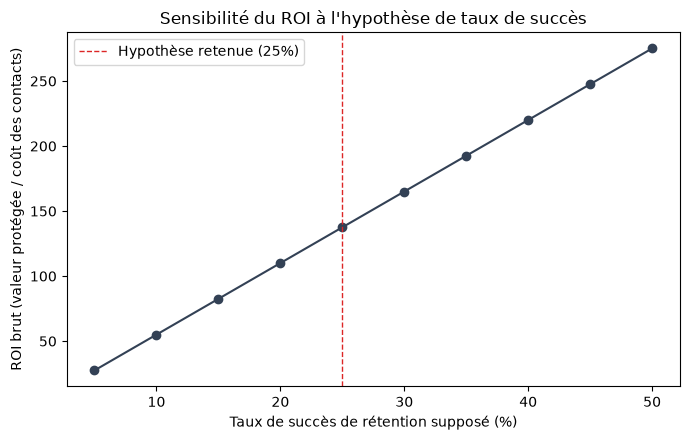

ROI même au taux le plus pessimiste testé (5%) : 27.5x


In [4]:
taux_a_tester = np.linspace(0.05, 0.50, 10)
roi_sensibilite = (clv_tp * taux_a_tester) / cout_operationnel

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(taux_a_tester * 100, roi_sensibilite, marker="o", color="#334155")
ax.axvline(25, color="#dc2626", ls="--", lw=1, label="Hypothèse retenue (25%)")
ax.set_xlabel("Taux de succès de rétention supposé (%)")
ax.set_ylabel("ROI brut (valeur protégée / coût des contacts)")
ax.set_title("Sensibilité du ROI à l'hypothèse de taux de succès")
ax.legend()
plt.tight_layout()
plt.savefig("figures/tp10_01_sensibilite_roi.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"ROI même au taux le plus pessimiste testé (5%) : {roi_sensibilite[0]:.1f}x")


**Le ROI reste largement positif même sous une hypothèse très pessimiste** (5% de
succès) — la conclusion ("le modèle rapporte plus qu'il ne coûte à opérer") est robuste
à l'incertitude sur cette hypothèse, ce qui n'aurait pas été garanti sans ce test de
sensibilité.

**Ce que le modèle ne résout pas** : environ 1,22M€ de CLV réelle (les faux négatifs,
§1) reste non détectée — des clients qui partent sans qu'aucune alerte n'ait été
déclenchée. Le modèle réduit l'exposition, il ne l'élimine pas.

## §2 — Dérive des données : une tentative honnête, et sa limite

In [5]:
df["date_souscription"] = pd.to_datetime(df["date_souscription"])
mediane_date = df["date_souscription"].median()
anciens = df[df["date_souscription"] < mediane_date]
recents = df[df["date_souscription"] >= mediane_date]

print(f"Médiane de date de souscription : {mediane_date.date()}")
print(f"Cohorte 'ancienne' : {len(anciens)}  |  Cohorte 'récente' : {len(recents)}")
print()

FEATURES_A_SURVEILLER = ["taux_adoption_pct", "derniere_connexion_jours", "nb_integrations", "csat"]
for col in FEATURES_A_SURVEILLER:
    ks = stats.ks_2samp(anciens[col].dropna(), recents[col].dropna())
    print(f"{col:28s} moy. ancienne={anciens[col].mean():6.2f}  moy. récente={recents[col].mean():6.2f}  KS p={ks.pvalue:.3f}")


Médiane de date de souscription : 2024-03-31
Cohorte 'ancienne' : 2492  |  Cohorte 'récente' : 2508

taux_adoption_pct            moy. ancienne= 49.18  moy. récente= 49.26  KS p=0.869
derniere_connexion_jours     moy. ancienne=  7.88  moy. récente=  7.29  KS p=0.785
nb_integrations              moy. ancienne=  3.37  moy. récente=  0.95  KS p=0.000
csat                         moy. ancienne=  3.41  moy. récente=  3.42  KS p=0.999


**Un signal de dérive apparent sur `nb_integrations`** (p < 0.001, moyenne 3.37 chez
les anciens contre 0.95 chez les récents) — les trois autres features ne bougent pas
(p > 0.7). Avant de le rapporter comme une vraie dérive de comportement, on vérifie
l'explication la plus simple : une confusion avec l'ancienneté elle-même.

In [6]:
corr_anciennete_date = df["date_souscription"].astype("int64").corr(df["anciennete_mois"])
corr_anciennete_integrations = df["anciennete_mois"].corr(df["nb_integrations"])

print(f"Corrélation (date_souscription, anciennete_mois) : {corr_anciennete_date:.4f}")
print(f"Corrélation (anciennete_mois, nb_integrations)    : {corr_anciennete_integrations:.4f}")


Corrélation (date_souscription, anciennete_mois) : -0.9997
Corrélation (anciennete_mois, nb_integrations)    : 0.6649


**Ce n'est pas une dérive — c'est un artefact mécanique du découpage.**
`date_souscription` et `anciennete_mois` sont presque parfaitement corrélées (-0.9997,
par construction : l'ancienneté se calcule à partir de la date de souscription).
Découper par date de souscription revient donc à découper par ancienneté — et
`nb_integrations` augmente naturellement avec le temps (corrélation 0.66, un client
récent n'a simplement pas encore eu le temps de connecter ses intégrations). L'écart
observé ne dit rien sur un changement de comportement des nouveaux clients.

**La bonne méthode, indisponible ici** : une vraie détection de dérive compare la
distribution des features de la population **scorée ce mois-ci** à celle du jeu
d'entraînement — pas deux sous-groupes internes d'un instantané unique. Ce jeu de
données, une photographie à un instant donné, ne permet pas cette comparaison ; elle
ne sera possible qu'une fois le pipeline de scoring mensuel (TP9) en production et
accumulant de l'historique.

## §3 — Plan de monitoring et de ré-entraînement

In [7]:
PLAN_MONITORING = pd.DataFrame([
    {"indicateur": "Distribution des features clés (TP7)", "frequence": "Mensuelle", "seuil_alerte": "Test KS p<0.01 vs distribution d'entraînement"},
    {"indicateur": "Taux de churn réel observé vs prédit", "frequence": "Mensuelle (avec retard d'1 échéance)", "seuil_alerte": "Écart > 5 points absolus"},
    {"indicateur": "PR-AUC sur les échéances résolues", "frequence": "Trimestrielle", "seuil_alerte": "Baisse > 0.05 vs 0.762 (référence TP6)"},
    {"indicateur": "Taux de succès réel des actions de rétention", "frequence": "Trimestrielle", "seuil_alerte": "Écart > 10 points vs hypothèse 25% (§1)"},
])
PLAN_MONITORING


,indicateur,frequence,seuil_alerte
0,Distribution des features clés (TP7),Mensuelle,Test KS p<0.01 vs distribution d'entraînement
1,Taux de churn réel observé vs prédit,Mensuelle (avec retard d'1 échéance),Écart > 5 points absolus
2,PR-AUC sur les échéances résolues,Trimestrielle,Baisse > 0.05 vs 0.762 (référence TP6)
3,Taux de succès réel des actions de rétention,Trimestrielle,Écart > 10 points vs hypothèse 25% (§1)


**Fréquence de ré-entraînement recommandée : trimestrielle**, ou déclenchée par
franchissement d'un seuil d'alerte du tableau ci-dessus — pas systématiquement à chaque
cycle mensuel de scoring (TP9), pour ne pas ré-entraîner sur un signal encore trop
bruité à un mois. Fenêtre de données : glissante sur les 12 derniers mois, pas
l'historique complet — un compte souscrit il y a 3 ans dans des conditions de marché
différentes n'est plus nécessairement représentatif du comportement actuel.

## §4 — Versioning

In [8]:
import hashlib
from datetime import datetime, timezone

# Empreinte du jeu de features (pas des données elles-mêmes) + horodatage —
# permet de savoir plus tard exactement quelle configuration a produit quel score.
signature_features = hashlib.sha256(",".join(FEATURE_COLS).encode()).hexdigest()[:12]

version_info = {
    "genere_le": datetime.now(timezone.utc).isoformat(),
    "signature_features": signature_features,
    "seuil_decision": SEUIL_DECISION,
    "metriques_reference": metadata["churn"],
}
print(json.dumps(version_info, indent=2, ensure_ascii=False))


{
  "genere_le": "2026-08-06T16:18:02.909810+00:00",
  "signature_features": "a9df25961ff7",
  "seuil_decision": 0.44,
  "metriques_reference": {
    "roc_auc": 0.8803,
    "pr_auc": 0.7615,
    "seuil_decision": 0.44
  }
}


Pas de MLflow ici (choix de périmètre assumé, à la différence du projet `ML/`) — une
signature du jeu de features + horodatage suffit à ce stade pour tracer quelle
configuration a produit quel lot de scores mensuel, sans ajouter d'infrastructure de
tracking dédiée pour un unique modèle en production.

## Journal de bord — Synthèse TP10

**Fait** :
- Impact métier chiffré à partir de la matrice de confusion réelle du test (TP=237,
  FN=43) : CLV totale à risque 12,17M€, dont 90% (10,95M€) correctement identifiée par
  le modèle.
- Hypothèse de taux de succès de rétention (25%) explicitée et testée en sensibilité —
  ROI positif même au scénario le plus pessimiste testé (5%).
- Tentative de détection de dérive **honnêtement invalidée** : l'écart observé sur
  `nb_integrations` est un artefact du découpage par ancienneté, pas une vraie dérive
  comportementale — limite clairement documentée plutôt que masquée.
- Plan de monitoring (4 indicateurs, fréquences et seuils d'alerte) et de
  ré-entraînement (trimestriel, fenêtre glissante 12 mois) proposés.
- Versioning minimal (signature des features + horodatage), proportionné au périmètre
  du projet.

**Reste à faire** :
- Notebook certifiant final — assembler TP1 à TP10 dans les 16 sections imposées par
  le règlement de la certification.